# Predicting Molecular Scent with MIST: Understanding the Discontinuous Chemistry of Smell

<a target="_blank" href="https://colab.research.google.com/github/BattModels/mist-demo/blob/main/tutorials/olfaction_prediction.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This tutorial demonstrates the olfaction model, which predicts how molecules smell to humans across 135 different odor descriptors.

- How to predict scent profiles for arbitrary molecules
- Why single-atom changes can drastically alter smell

Unlike many molecular properties that depend purely on structure, smell is a psychophysical phenomenon involving human perception. A single atom substitution can transform a pleasant-smelling compound into something foul!


In [1]:
# Install dependencies
! pip install -q transformers torch rdkit plotly pandas numpy


In [2]:
import torch
import numpy as np
import plotly.graph_objects as go
from transformers import AutoModel
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

/Users/anoushka/VSCodeProjects/mist-demo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


In [3]:
# Some utils to process inputs and outputs

def kekulize_smiles(smiles):
    """
    Convert SMILES to kekulized form (explicit single/double bonds).
    MIST olfaction model was trained on kekulized SMILES.
    
    Args:
        smiles: Input SMILES string
    Returns:
        Kekulized SMILES string
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    Chem.Kekulize(mol)
    return Chem.MolToSmiles(mol, kekuleSmiles=True)

def get_top_scents(predictions, threshold=0.5, top_n=None):
    """
    Extract predicted scent descriptors above threshold.
    
    Args:
        predictions: Dictionary from model.predict()
        threshold: Probability threshold for positive prediction
        top_n: If set, return only top N predictions by probability
    Returns:
        List of (descriptor, probability) tuples
    """
    scents = []
    for descriptor, pred_dict in predictions.items():
        logit = pred_dict['value'][0]
        # Convert tensor to Python float if needed
        if hasattr(logit, 'item'):
            logit = logit.item()
        prob = 1 / (1 + np.exp(-logit))  # sigmoid
        if prob >= threshold:
            scents.append((descriptor, float(prob)))
    
    scents.sort(key=lambda x: x[1], reverse=True)
    if top_n:
        scents = scents[:top_n]
    return scents

In [4]:
# Loading the model
model_name = "mist-models/mist-26.9M-48kpooqf-odour"
model = AutoModel.from_pretrained(model_name, trust_remote_code=True).to(device).eval()

One of the most fascinating aspects of olfaction is its discontinuity: small structural changes can produce dramatic shifts in perceived scent.

Here, we explore this using the example of Acetone and Thioacetone
- **Acetone** `CC(=O)C`: Has an oxygen atom, smells ethereal/fruity (nail polish remover)
- **Thioacetone** `CC(=S)C`: Replace oxygen with sulfur, smells intensely sulfurous/meaty

This single-atom substitution (`O` to `S`) transforms a common solvent into one of the most foul-smelling compounds known!

Let's see if `MIST` captures this discontinuity:

In [5]:
molecules = {
    'Acetone': 'CC(=O)C',
    'Thioacetone': 'CC(=S)C'
}

for name, smiles in molecules.items():
    kek_smiles = kekulize_smiles(smiles)
    predictions = model.predict([kek_smiles])
    top_scents = get_top_scents(predictions, threshold=0.0, top_n=5)  # Get top 5
    
    print(f"{name} ({smiles})")
    for descriptor, prob in top_scents:
        print(f"  {descriptor} {prob:.3f}")

Acetone (CC(=O)C)
  fruity 0.923
  ethereal 0.830
  sweet 0.728
  pungent 0.525
  fermented 0.407
Thioacetone (CC(=S)C)
  sulfurous 0.947
  meaty 0.724
  garlic 0.586
  onion 0.580
  savory 0.358


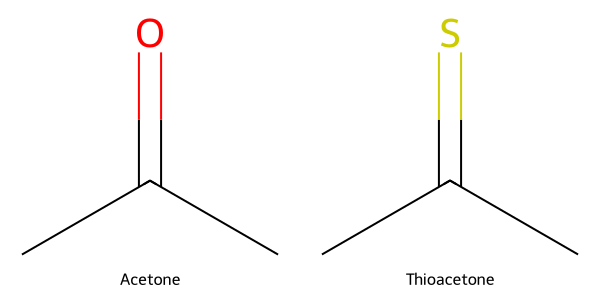

In [6]:
# Visualize the molecular structures
mols = [Chem.MolFromSmiles(smi) for smi in molecules.values()]
labels = list(molecules.keys())

img = Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(300, 300), legends=labels)
display(img)

**Observations:**
- **Acetone**: Predicted as "ethereal" - matches the common description of nail polish remover
- **Thioacetone**: Predicted as "sulfurous" and "meaty" - captures the foul, organosulfur character

The model successfully learns this **discontinuous mapping** from structure to odor, showing that it's not just matching molecular similarity but learning the complex chemistry of smell!

**Why this matters**: In fragrance design and flavor chemistry, small structural tweaks can have unpredictable effects. MIST helps predict these effects before expensive synthesis.


Use the function below to predict scents for any molecule.

**Suggestions to try:**
- Common solvents: ethanol, acetone, benzene
- Natural products: vanillin, limonene, menthol
- Functional group variations: swap O for S, add/remove double bonds

In [10]:
def predict_and_display(smiles, name="Molecule", threshold=0.3):
    """
    Predict and display scent profile for a molecule.
    
    Args:
        smiles: SMILES string
        name: Molecule name for display
        threshold: Probability threshold for displaying descriptors
    """
    try:
        kek_smiles = kekulize_smiles(smiles)
        predictions = model.predict([kek_smiles])
        scents = get_top_scents(predictions, threshold=threshold)
        
        mol = Chem.MolFromSmiles(smiles)
        img = Draw.MolToImage(mol, size=(400, 400))
        display(img)
        
        print(f"\n{name}")
        print("="*60)
        print(f"SMILES: {smiles}")
        print(f"Predicted Scent Profile (threshold={threshold}):")
        
        if scents:
            descriptors = [s[0] for s in scents]
            probs = [s[1] for s in scents]
            
            fig = go.Figure(data=[
                go.Bar(
                    x=probs,
                    y=descriptors,
                    orientation='h',
                    marker=dict(color=probs, colorscale='Blues')
                )
            ])
            
            fig.update_layout(
                title=f"Scent Profile: {name}",
                xaxis_title="Probability",
                yaxis_title="Odor Descriptor",
                template='simple_white',
                height=max(300, len(scents) * 40 + 100),
                showlegend=False
            )
            
            fig.show()
            
        else:
            print(f"  (No descriptors above threshold {threshold})")
            
    except Exception as e:
        print(f"Error processing molecule: {e}")

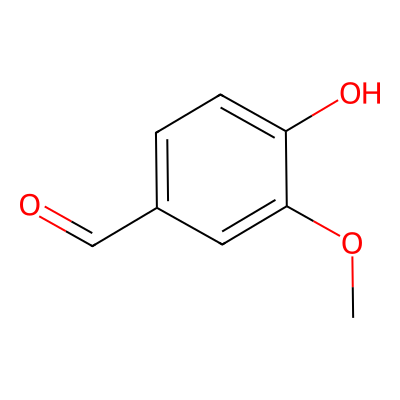


Vanillin
SMILES: COc1cc(C=O)ccc1O
Predicted Scent Profile (threshold=0.4):


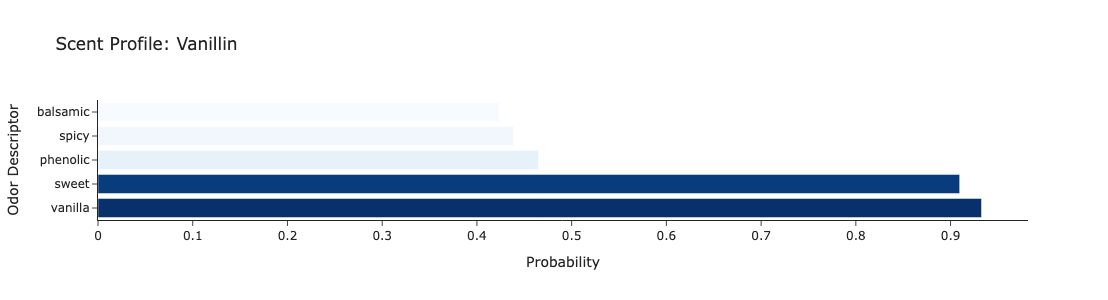


------------------------------------------------------------



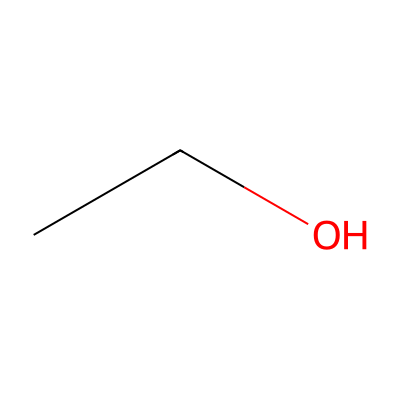


Ethanol
SMILES: CCO
Predicted Scent Profile (threshold=0.4):


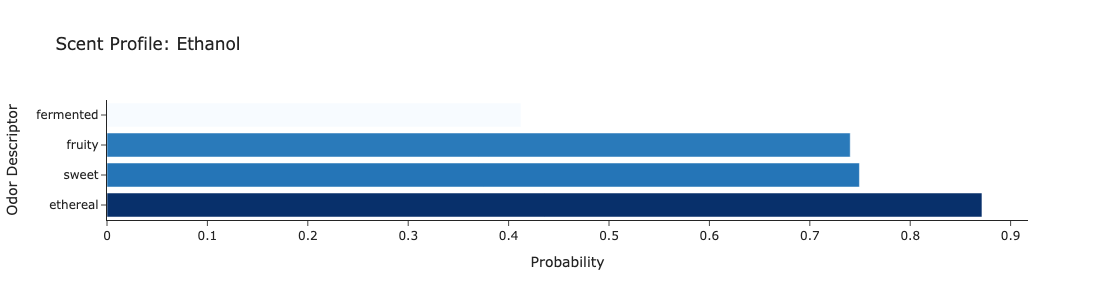


------------------------------------------------------------



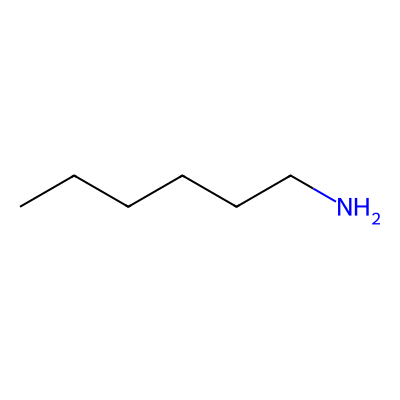


Hexylamine
SMILES: CCCCCCN
Predicted Scent Profile (threshold=0.4):


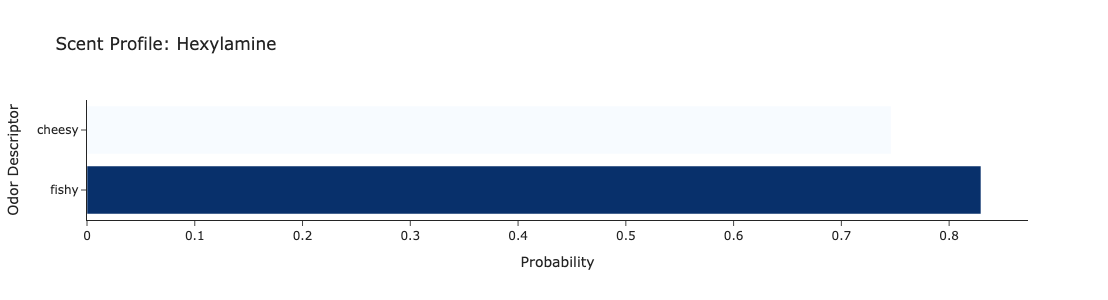


------------------------------------------------------------



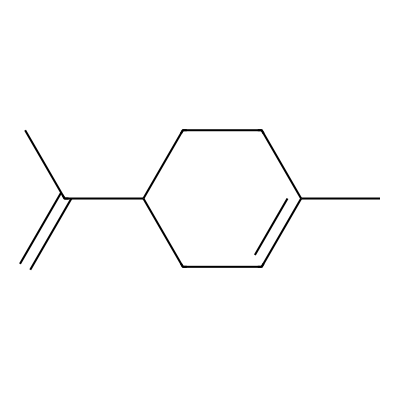


Limonene
SMILES: CC1=CCC(CC1)C(=C)C
Predicted Scent Profile (threshold=0.4):


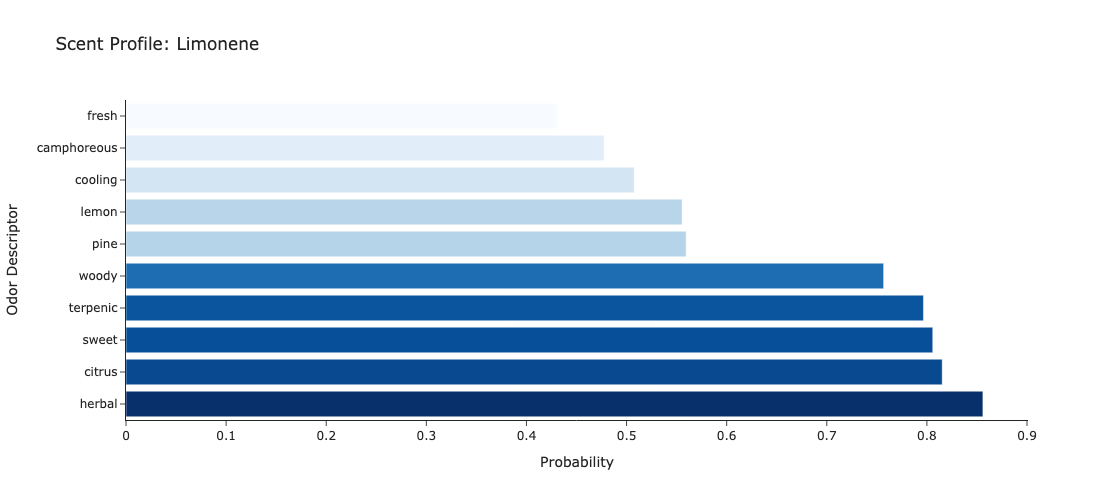


------------------------------------------------------------



In [12]:
examples = [
    ("COc1cc(C=O)ccc1O", "Vanillin"),  # Vanilla extract
    ("CCO", "Ethanol"),  # Drinking alcohol
    ("CCCCCCN", "Hexylamine"),  # Primary amine
    ("CC1=CCC(CC1)C(=C)C", "Limonene"),  # Citrus peel
]

for smiles, name in examples:
    predict_and_display(smiles, name, threshold=0.4)
    print("\n" + "-"*60 + "\n")

In [ ]:
# Try your own molecule!
# Uncomment and modify:

# your_smiles = "CC(C)=O"  # Acetone
# predict_and_display(your_smiles, "Your Molecule", threshold=0.3)

**References:**
- MIST Paper: [Molecular Insight SMILES Transformer](https://arxiv.org/abs/2510.18900)
- OpenPOM Dataset: [Open Principal Odor Map](https://github.com/...)